In [1]:
import pandas as pd
train_df = pd.read_csv(r"C:\Users\chill\OneDrive\Documents\ML-DS Competition\StudentHealthRisk\datasets\train.csv")
test_df = pd.read_csv(r"C:\Users\chill\OneDrive\Documents\ML-DS Competition\StudentHealthRisk\datasets\test.csv")

train_df.head(3)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male


In [2]:
print("shape of train dataset: ", train_df.shape)
print("shape of test dataset: ", test_df.shape)

shape of train dataset:  (690088, 15)
shape of test dataset:  (295753, 14)


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [5]:
df = train_df.iloc[:,1:]
df.columns

Index(['health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [5]:
df.describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [6]:
df.isnull().sum()

health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [11]:
total_null_val = df.isnull().sum().sum()
total_records = int(df.shape[0] * df.shape[1])
print(f"total number of null values in train data: {df.isnull().sum().sum()}")
print(f"null percentage: {(total_null_val/total_records)*100:.2f} %")

total number of null values in train data: 449496
null percentage: 4.65 %


In [12]:
total_null_val = test_df.isnull().sum().sum()
total_records = int(test_df.shape[0] * test_df.shape[1])
print(f"total number of null values in test data: {test_df.isnull().sum().sum()}")
print(f"null percentage: {(total_null_val/total_records)*100:.2f} %")

total number of null values in test data: 192642
null percentage: 4.65 %


In [7]:
# find outliers
def find_outliers(df, column):
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outliers
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    return outliers


In [8]:
y = df["health_condition"]
X = df.drop("health_condition", axis=1)
X.columns

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')

In [9]:
# select numerical and categorical cols in train
numerical_cols = []
categorical_cols = []

for col in X.columns:
    if X[col].dtype == "object":
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

In [10]:
print("numerical cols: \n", [cols for cols in numerical_cols])
print("categorical cols: \n", [cols for cols in categorical_cols])

numerical cols: 
 ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
categorical cols: 
 ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


<Axes: title={'center': 'Box plot of numerical columns'}>

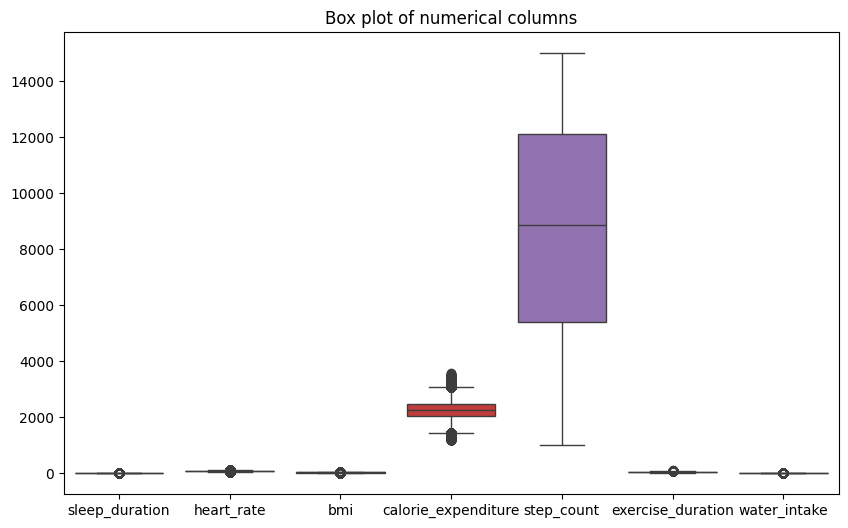

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
plt.title(label="Box plot of numerical columns")
sns.boxplot(data=df[numerical_cols])

In [11]:
for col in numerical_cols:   
    outlier_count = find_outliers(df=X, column=col)
    print(f"{col}: {outlier_count}")


sleep_duration: 2020
heart_rate: 2825
bmi: 5352
calorie_expenditure: 12831
step_count: 0
exercise_duration: 104
water_intake: 11388


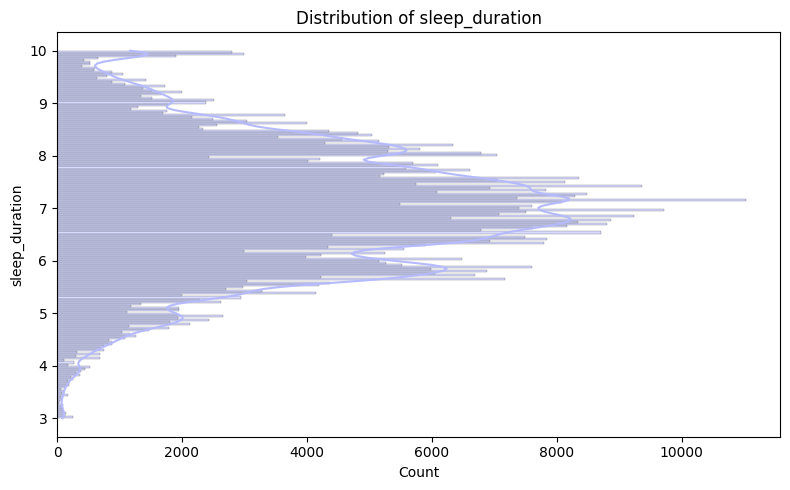

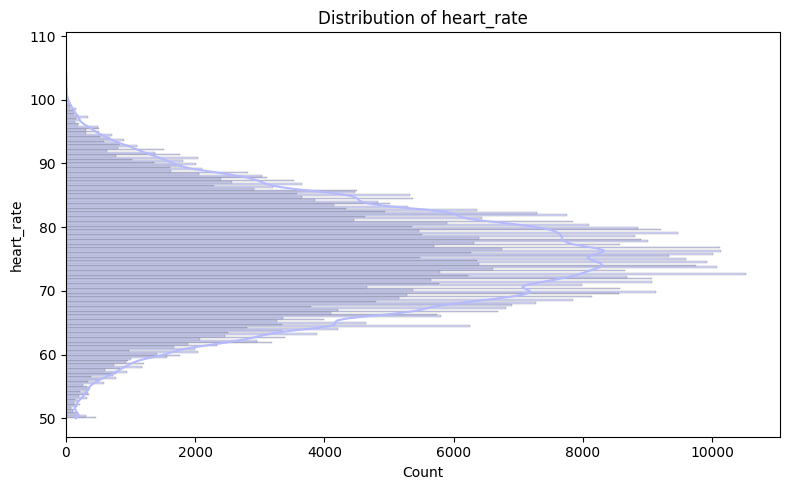

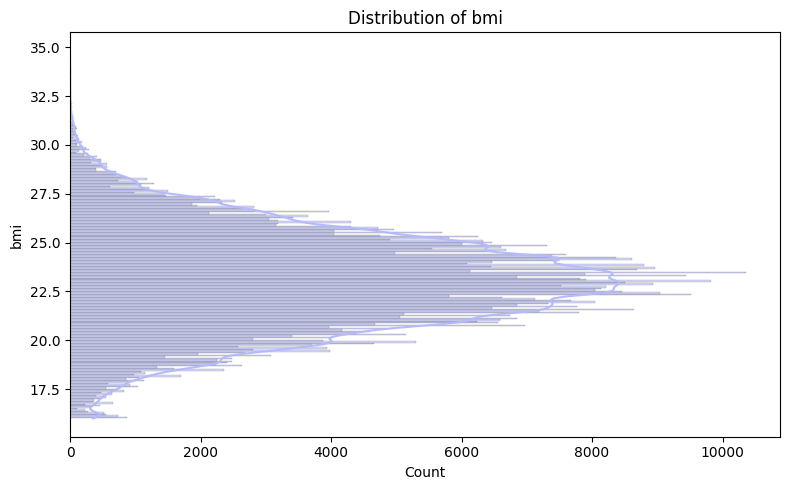

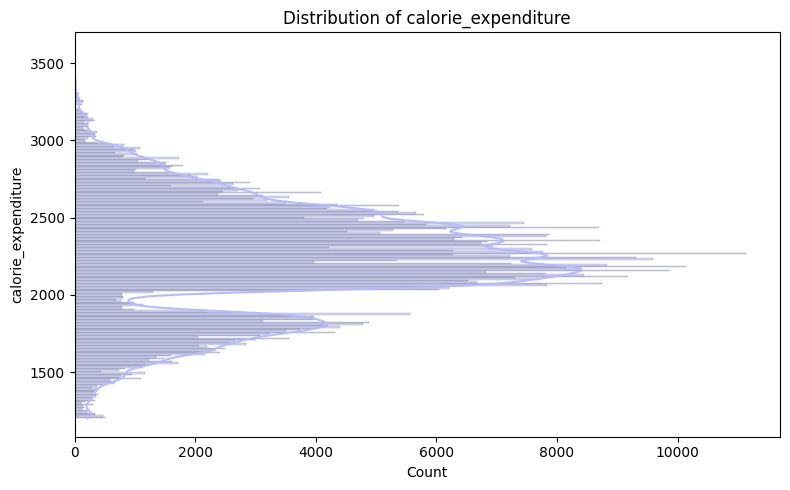

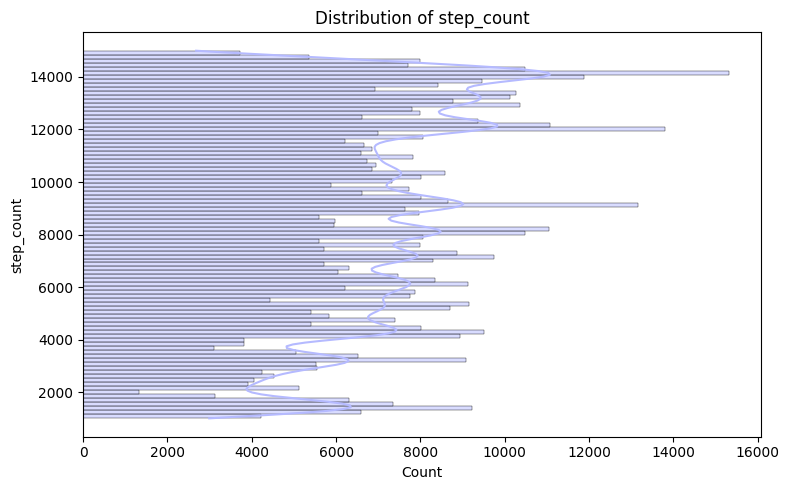

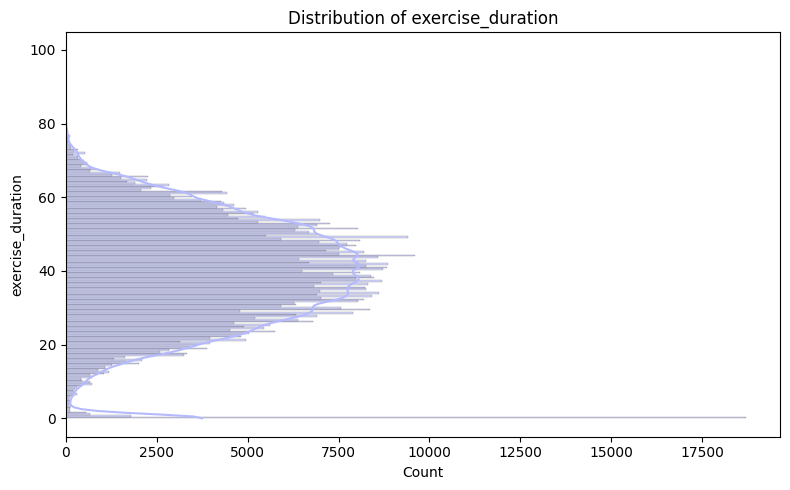

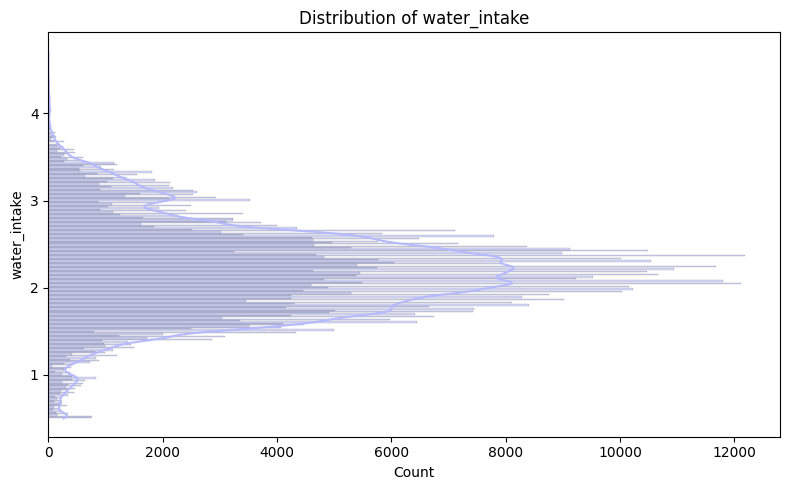

In [28]:
def plot_histogram(column):
    plt.figure(figsize=(8,5))
    plt.title(f"Distribution of {column}")
    sns.histplot(data=X, y=column, kde=True, color="#B5BAFF")
    plt.tight_layout()
    plt.plot()

for col in numerical_cols:
    plot_histogram(column=col)

In [12]:
print(categorical_cols)
print("\n", numerical_cols)

['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

 ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


In [36]:
df['sleep_duration'].head()

0    5.22
1    5.53
2    5.29
3    4.70
4    7.23
Name: sleep_duration, dtype: float64

In [13]:
for cols in categorical_cols:
    print(f"{cols}: {X[cols].unique()}")

diet_type: ['veg' 'non-veg' 'balanced' nan]
stress_level: ['high' 'low' nan 'medium']
sleep_quality: ['average' 'poor' nan 'good']
physical_activity_level: ['sedentary' 'moderate' 'active' nan]
smoking_alcohol: ['yes' 'occasional' nan 'no']
gender: ['female' 'other' 'male' nan]


In [19]:
ordinal_cols = ["stress_level", "sleep_quality", "physical_activity_level"]
categorical_cols = ["diet_type", "smoking_alcohol","gender"]

In [17]:
for cols in categorical_cols:
    print(X[cols].value_counts().reset_index().sort_values(ascending=False, by=cols))
    print("---------------------------------------")

  diet_type   count
0       veg  231432
2   non-veg  224867
1  balanced  226888
---------------------------------------
  smoking_alcohol   count
0             yes  223730
2      occasional  217985
1              no  219791
---------------------------------------
   gender   count
2   other  206943
0    male  237756
1  female  224016
---------------------------------------


In [22]:
df["health_condition"].value_counts().reset_index()

,health_condition,count
0,at-risk,592561
1,unhealthy,57724
2,fit,39803


In [20]:
for cols in ordinal_cols:
    print(X[cols].value_counts().reset_index().sort_values(ascending=False, by=cols))
    print("---------------------------------------")

  stress_level   count
0       medium  261819
2          low  167708
1         high  177750
---------------------------------------
  sleep_quality   count
1          poor  212166
2          good  205643
0       average  213948
---------------------------------------
  physical_activity_level   count
1               sedentary  219784
0                moderate  221041
2                  active  212642
---------------------------------------


In [37]:
# creating pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

cat_preprocessor = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_preprocessor = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder())
])

num_preprocessor = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ("scale", StandardScaler())    
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", cat_preprocessor, categorical_cols),
    ("ord", ord_preprocessor, ordinal_cols),
    ("num", num_preprocessor, numerical_cols)
])

In [24]:
def evaluate(model, X_test, y_test):
    from sklearn.metrics import  balanced_accuracy_score
    y_pred = model.predict(X_test)
    accuracy = balanced_accuracy_score(y_test, y_pred)
    return accuracy

In [29]:
y = y.str.replace("at-risk","risk")
y = y.str.replace("fit","healthy")
y.unique()

array(['unhealthy', 'risk', 'healthy'], dtype=object)

In [31]:
y = y.map({
    "healthy":0,
    "unhealthy":1,
    "risk":2
})
y.tail(3)

690085    0
690086    2
690087    2
Name: health_condition, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42, shuffle=True)
print(f"X train:{X_train.shape}\nX test: {X_test.shape}\ny train: {y_train.shape}\ny test: {y_test.shape}")

X train:(538268, 13)
X test: (151820, 13)
y train: (538268,)
y test: (151820,)


In [38]:
from sklearn.linear_model import LogisticRegression
lr = Pipeline(steps=[
    ("prep", preprocessor),
    ('model', LogisticRegression())
])
lr.fit(X_train, y_train)
accuracy_lr = evaluate(model=lr, X_test=X_test, y_test=y_test)
print("lr accuracy = ", accuracy_lr)

lr accuracy =  0.5923148417436597


In [42]:
from sklearn.tree import DecisionTreeClassifier
dt = Pipeline(steps=[
    ("prep", preprocessor),
    ('model', DecisionTreeClassifier(max_depth=9, criterion='entropy', splitter="best"))
])
dt.fit(X_train, y_train)
accuracy_dt = evaluate(model=dt, X_test=X_test, y_test=y_test)
print("dt accuracy = ", accuracy_dt)

dt accuracy =  0.8517564965142083


In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ('model', RandomForestClassifier(max_depth=7, n_estimators=300, verbose=2, n_jobs=-1, criterion='entropy', random_state=42))
])
rf.fit(X_train, y_train)
accuracy_rf = evaluate(model=rf, X_test=X_test, y_test=y_test)
print("rf accuracy = ", accuracy_rf)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.3s


building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300building tree 48 of 300

building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73

[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   13.8s


building tree 155 of 300
building tree 156 of 300
building tree 157 of 300
building tree 158 of 300building tree 159 of 300

building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   28.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.1s


rf accuracy =  0.7068419736352126


[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.3s finished


In [43]:
from lightgbm import LGBMClassifier
lgb = Pipeline(steps=[
    ("prep", preprocessor),
    ('model', LGBMClassifier())
])
lgb.fit(X_train, y_train)
accuracy_lgb = evaluate(model=lgb, X_test=X_test, y_test=y_test)
print("lr accuracy = ", accuracy_lgb)

c:\Users\chill\OneDrive\Documents\ML-DS Competition\comp\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lr accuracy =  0.8569133157397594
